Single Metric Results:
  Euclidean raw: CH=713.93 ACC=67.95%
  Cosine raw:    CH=663.61 ACC=73.29%
  PCA Euclid:    CH=725.35 ACC=68.45%

Integrated vs Trajectory:
  Integrated: CH=724.80 ACC=70.40%
  Trajectory [0, 1, 2, 1, 0, 2]: CH=623.27 ACC=76.02%

Best Random Trajectory (CH): ([np.int64(2), np.int64(0), np.int64(2), np.int64(1), np.int64(2), np.int64(1), np.int64(2), np.int64(1)], 692.607445202907, np.float64(0.8224819143016138))
Best Random Trajectory (ACC): ([np.int64(0), np.int64(0), np.int64(2), np.int64(1), np.int64(0), np.int64(1), np.int64(0), np.int64(1)], 662.935069763025, np.float64(0.8297161936560935))

=== Summary ===
Best Single Metric:   CH=725.35 ACC=73.29%
Integrated Operator:  CH=724.80 ACC=70.40%
Best Traj (CH):       CH=692.61 ACC=82.25%
Best Traj (ACC):      CH=662.94 ACC=82.97%


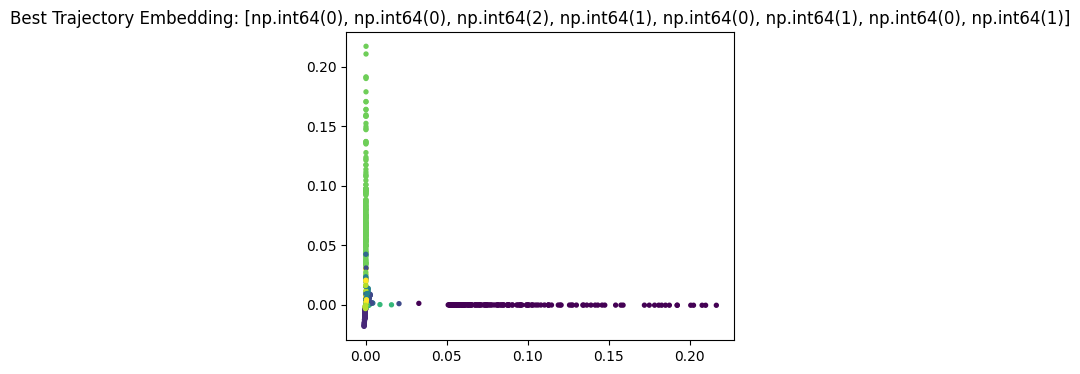

In [1]:
# ============================================================
# Multi-Metric Diffusion Trajectories on a Real Dataset (Digits)
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_digits
from sklearn.decomposition import PCA
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import normalize
from sklearn.cluster import KMeans
from sklearn.metrics import calinski_harabasz_score
from numpy.linalg import eigh

rng = np.random.RandomState(42)

# ------------------------------------------------------------
# 1. Load Digits Dataset
# ------------------------------------------------------------
digits = load_digits()
X_raw = digits.data.astype(float)
y = digits.target
X_raw /= 16.0  # normalize pixels to 0-1

# ------------------------------------------------------------
# 2. Make alternate geometric views of the same data
# ------------------------------------------------------------
# View C: PCA embedding
pca = PCA(n_components=20, random_state=rng)
X_pca = pca.fit_transform(X_raw)

# ------------------------------------------------------------
# 3. Build diffusion operator from metric
# ------------------------------------------------------------
def build_random_walk_matrix(X, n_neighbors=15, metric="euclidean"):
    nn = NearestNeighbors(n_neighbors=n_neighbors, metric=metric)
    nn.fit(X)
    distances, indices = nn.kneighbors(X)

    n = X.shape[0]
    W = np.zeros((n, n), float)
    for i in range(n):
        for j in indices[i]:
            W[i, j] = 1.0

    P = normalize(W, norm="l1", axis=1)
    return P

P_A = build_random_walk_matrix(X_raw, metric="euclidean")
P_B = build_random_walk_matrix(X_raw, metric="cosine")
P_C = build_random_walk_matrix(X_pca, metric="euclidean")

P_list = [P_A, P_B, P_C]

# ------------------------------------------------------------
# 4. Diffusion Embedding Function
# ------------------------------------------------------------
def diffusion_embedding(P, n_components=10, t=5):
    S = 0.5 * (P + P.T)
    evals, evecs = eigh(S)
    idx = np.argsort(evals)[::-1]
    evals = evals[idx]
    evecs = evecs[:, idx]

    lambdas = evals[1:n_components+1]
    psi = evecs[:, 1:n_components+1]

    lambdas_t = lambdas**t
    Z = psi * lambdas_t
    return Z

# Compute embeddings
Z_A = diffusion_embedding(P_A)
Z_B = diffusion_embedding(P_B)
Z_C = diffusion_embedding(P_C)

# ------------------------------------------------------------
# 5. Clustering Evaluation
# ------------------------------------------------------------
def evaluate_embedding(Z, y_true, n_clusters=10):
    km = KMeans(n_clusters=n_clusters, n_init=20, random_state=rng)
    labels_pred = km.fit_predict(Z)

    ch = calinski_harabasz_score(Z, labels_pred)

    cluster_to_label = {}
    for k in range(n_clusters):
        mask = (labels_pred == k)
        if np.sum(mask) == 0:
            cluster_to_label[k] = -1
        else:
            majority = np.bincount(y_true[mask]).argmax()
            cluster_to_label[k] = majority

    mapped_preds = np.array([cluster_to_label[c] for c in labels_pred])
    acc = np.mean(mapped_preds == y_true)
    return ch, acc

scores_A = evaluate_embedding(Z_A, y)
scores_B = evaluate_embedding(Z_B, y)
scores_C = evaluate_embedding(Z_C, y)

print("Single Metric Results:")
print("  Euclidean raw: CH=%.2f ACC=%.2f%%" % (scores_A[0], scores_A[1]*100))
print("  Cosine raw:    CH=%.2f ACC=%.2f%%" % (scores_B[0], scores_B[1]*100))
print("  PCA Euclid:    CH=%.2f ACC=%.2f%%" % (scores_C[0], scores_C[1]*100))

# ------------------------------------------------------------
# 6. Integrated and Trajectory Operators
# ------------------------------------------------------------
def integrated_operator(P_list):
    P_int = sum(P_list)/len(P_list)
    return normalize(P_int, norm="l1", axis=1)

def trajectory_operator(P_list, trajectory):
    n = P_list[0].shape[0]
    P_traj = np.eye(n)
    for idx in trajectory:
        P_traj = P_list[idx] @ P_traj
    return normalize(P_traj, norm="l1", axis=1)

P_int = integrated_operator(P_list)

trajectory_example = [0,1,2,1,0,2]
P_traj_example = trajectory_operator(P_list, trajectory_example)

Z_int = diffusion_embedding(P_int)
Z_traj_example = diffusion_embedding(P_traj_example, t=1)

scores_int = evaluate_embedding(Z_int, y)
scores_traj_example = evaluate_embedding(Z_traj_example, y)

print("\nIntegrated vs Trajectory:")
print("  Integrated: CH=%.2f ACC=%.2f%%" % (scores_int[0], scores_int[1]*100))
print("  Trajectory %s: CH=%.2f ACC=%.2f%%" %
      (trajectory_example, scores_traj_example[0], scores_traj_example[1]*100))

# ------------------------------------------------------------
# 7. Random Trajectories Experiment
# ------------------------------------------------------------
def random_trajectory(num_views, length):
    return list(rng.randint(0, num_views, size=length))

n_random = 30
traj_length = 8
traj_results = []

for _ in range(n_random):
    tr = random_trajectory(len(P_list), traj_length)
    P_tr = trajectory_operator(P_list, tr)
    Z_tr = diffusion_embedding(P_tr, t=1)
    ch, acc = evaluate_embedding(Z_tr, y)
    traj_results.append((tr, ch, acc))

traj_results.sort(key=lambda x: x[1], reverse=True)
best_traj_ch = traj_results[0]

traj_results.sort(key=lambda x: x[2], reverse=True)
best_traj_acc = traj_results[0]

print("\nBest Random Trajectory (CH):", best_traj_ch)
print("Best Random Trajectory (ACC):", best_traj_acc)

# ------------------------------------------------------------
# 8. Summary Comparison
# ------------------------------------------------------------
best_single_CH = max(scores_A[0], scores_B[0], scores_C[0])
best_single_ACC = max(scores_A[1], scores_B[1], scores_C[1])

print("\n=== Summary ===")
print("Best Single Metric:   CH=%.2f ACC=%.2f%%" % (best_single_CH, best_single_ACC*100))
print("Integrated Operator:  CH=%.2f ACC=%.2f%%" % (scores_int[0], scores_int[1]*100))
print("Best Traj (CH):       CH=%.2f ACC=%.2f%%" % (best_traj_ch[1], best_traj_ch[2]*100))
print("Best Traj (ACC):      CH=%.2f ACC=%.2f%%" % (best_traj_acc[1], best_traj_acc[2]*100))


# ------------------------------------------------------------
# 9. Visualize Best Trajectory (optional)
# ------------------------------------------------------------
best_traj = best_traj_acc[0]
P_best = trajectory_operator(P_list, best_traj)
Z_best = diffusion_embedding(P_best, t=1)

plt.figure(figsize=(5,4))
plt.scatter(Z_best[:,0], Z_best[:,1], c=y, s=8)
plt.title("Best Trajectory Embedding: %s" % best_traj)
plt.show()

In [2]:
# ============================================================
# Multi-Metric Diffusion on Multiple Datasets
# Confirming the "same data, many geometries" hypothesis
# ============================================================

import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_digits, load_iris, load_wine, load_breast_cancer
from sklearn.preprocessing import StandardScaler, normalize
from sklearn.decomposition import PCA
from sklearn.neighbors import NearestNeighbors
from sklearn.cluster import KMeans
from sklearn.metrics import calinski_harabasz_score
from numpy.linalg import eigh

rng = np.random.RandomState(42)

# ------------------------------------------------------------
# Utility: build random walk diffusion operator from metric
# ------------------------------------------------------------
def build_random_walk_matrix(X, n_neighbors=15, metric="euclidean", metric_params=None):
    """
    X: (n_samples, n_features)
    n_neighbors: k for k-NN graph
    metric: string metric name for NearestNeighbors
    metric_params: optional dict for metric parameters (e.g. VI for mahalanobis)
    """
    n_neighbors = min(n_neighbors, X.shape[0] - 1)
    nn = NearestNeighbors(
        n_neighbors=n_neighbors,
        metric=metric,
        metric_params=metric_params
    )
    nn.fit(X)
    distances, indices = nn.kneighbors(X)

    n = X.shape[0]
    W = np.zeros((n, n), float)
    for i in range(n):
        for j in indices[i]:
            W[i, j] = 1.0

    P = normalize(W, norm="l1", axis=1)
    return P

# ------------------------------------------------------------
# Diffusion embedding
# ------------------------------------------------------------
def diffusion_embedding(P, n_components=10, t=5):
    """
    Simple diffusion embedding from random walk matrix P.
    - Symmetrize
    - Eigen-decompose
    - Use top non-trivial components
    """
    S = 0.5 * (P + P.T)
    evals, evecs = eigh(S)
    idx = np.argsort(evals)[::-1]
    evals = evals[idx]
    evecs = evecs[:, idx]

    lambdas = evals[1:n_components+1]
    psi = evecs[:, 1:n_components+1]

    lambdas_t = lambdas**t
    Z = psi * lambdas_t
    return Z

# ------------------------------------------------------------
# Clustering evaluation
# ------------------------------------------------------------
def evaluate_embedding(Z, y_true, n_clusters=None):
    """
    KMeans in diffusion space -> CH score + "cluster accuracy" vs true labels
    """
    if n_clusters is None:
        n_clusters = len(np.unique(y_true))

    km = KMeans(n_clusters=n_clusters, n_init=20, random_state=rng)
    labels_pred = km.fit_predict(Z)

    ch = calinski_harabasz_score(Z, labels_pred)

    cluster_to_label = {}
    for k in range(n_clusters):
        mask = (labels_pred == k)
        if np.sum(mask) == 0:
            cluster_to_label[k] = -1
        else:
            majority = np.bincount(y_true[mask]).argmax()
            cluster_to_label[k] = majority

    mapped_preds = np.array([cluster_to_label[c] for c in labels_pred])
    acc = np.mean(mapped_preds == y_true)
    return ch, acc

# ------------------------------------------------------------
# Integrated + trajectory operators
# ------------------------------------------------------------
def integrated_operator(P_list, weights=None):
    m = len(P_list)
    if weights is None:
        weights = np.ones(m) / m
    P_int = np.zeros_like(P_list[0])
    for w, P in zip(weights, P_list):
        P_int += w * P
    P_int = normalize(P_int, norm="l1", axis=1)
    return P_int

def trajectory_operator(P_list, trajectory):
    """
    P_traj = P_{i_T} ... P_{i_1}
    trajectory: list of indices into P_list
    """
    n = P_list[0].shape[0]
    P_traj = np.eye(n)
    for idx in trajectory:
        P_traj = P_list[idx] @ P_traj
    P_traj = normalize(P_traj, norm="l1", axis=1)
    return P_traj

def random_trajectory(num_views, length):
    return list(rng.randint(0, num_views, size=length))

# ------------------------------------------------------------
# Dataset loader helper
# ------------------------------------------------------------
def load_all_datasets():
    datasets = {}

    # Digits
    d_digits = load_digits()
    Xd = d_digits.data.astype(float)
    yd = d_digits.target
    datasets["digits"] = (Xd, yd)

    # Iris
    d_iris = load_iris()
    Xi = d_iris.data.astype(float)
    yi = d_iris.target
    datasets["iris"] = (Xi, yi)

    # Wine
    d_wine = load_wine()
    Xw = d_wine.data.astype(float)
    yw = d_wine.target
    datasets["wine"] = (Xw, yw)

    # Breast cancer
    d_bc = load_breast_cancer()
    Xb = d_bc.data.astype(float)
    yb = d_bc.target
    datasets["breast_cancer"] = (Xb, yb)

    return datasets

# ------------------------------------------------------------
# Main experiment over multiple datasets
# ------------------------------------------------------------
datasets = load_all_datasets()

results_summary = []

for name, (X_raw, y) in datasets.items():
    print("\n" + "="*70)
    print("DATASET:", name, "  shape:", X_raw.shape, "  classes:", np.unique(y))
    print("="*70)

    # 1) standardize features
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X_raw)

    # 2) PCA view
    n_components_pca = min(20, X_scaled.shape[1])
    pca = PCA(n_components=n_components_pca, random_state=rng)
    X_pca = pca.fit_transform(X_scaled)

    # 3) Mahalanobis VI matrix
    cov = np.cov(X_scaled, rowvar=False)
    VI = np.linalg.pinv(cov)

    # Build diffusion operators for 4 metrics
    P_list = []
    metric_names = []

    # A) Euclidean on standardized raw
    P_euc = build_random_walk_matrix(X_scaled, n_neighbors=15,
                                     metric="euclidean", metric_params=None)
    P_list.append(P_euc)
    metric_names.append("euclidean_raw")

    # B) Cosine on standardized raw
    P_cos = build_random_walk_matrix(X_scaled, n_neighbors=15,
                                     metric="cosine", metric_params=None)
    P_list.append(P_cos)
    metric_names.append("cosine_raw")

    # C) Euclidean on PCA features
    P_pca = build_random_walk_matrix(X_pca, n_neighbors=15,
                                     metric="euclidean", metric_params=None)
    P_list.append(P_pca)
    metric_names.append("euclidean_pca")

    # D) Mahalanobis on standardized raw
    P_mah = build_random_walk_matrix(X_scaled, n_neighbors=15,
                                     metric="mahalanobis", metric_params={"VI": VI})
    P_list.append(P_mah)
    metric_names.append("mahalanobis_raw")

    # Single-metric embeddings and scores
    single_scores = []
    for i, (P, mname) in enumerate(zip(P_list, metric_names)):
        Z = diffusion_embedding(P, n_components=10, t=5)
        ch, acc = evaluate_embedding(Z, y)
        single_scores.append((mname, ch, acc))

    print("Single Metric Results:")
    for mname, ch, acc in single_scores:
        print("  %-15s -> CH=%8.2f  ACC=%6.2f%%" % (mname, ch, acc*100))

    # Best single metric (by ACC)
    best_single = max(single_scores, key=lambda x: x[2])
    best_single_CH = best_single[1]
    best_single_ACC = best_single[2]

    # Integrated operator
    P_int = integrated_operator(P_list)
    Z_int = diffusion_embedding(P_int, n_components=10, t=5)
    ch_int, acc_int = evaluate_embedding(Z_int, y)

    print("\nIntegrated Operator:")
    print("  CH=%8.2f  ACC=%6.2f%%" % (ch_int, acc_int*100))

    # Random trajectories
    n_random_traj = 40
    traj_length = 8
    traj_results = []

    for _ in range(n_random_traj):
        tr = random_trajectory(len(P_list), traj_length)
        P_tr = trajectory_operator(P_list, tr)
        Z_tr = diffusion_embedding(P_tr, n_components=10, t=1)
        ch_tr, acc_tr = evaluate_embedding(Z_tr, y)
        traj_results.append((tr, ch_tr, acc_tr))

    # Best trajectories by CH and ACC
    best_by_CH = max(traj_results, key=lambda x: x[1])
    best_by_ACC = max(traj_results, key=lambda x: x[2])

    best_traj_CH = [int(i) for i in best_by_CH[0]]
    best_traj_ACC = [int(i) for i in best_by_ACC[0]]

    print("\nBest Random Trajectory (by CH):")
    print("  Trajectory:", best_traj_CH)
    print("  CH=%8.2f  ACC=%6.2f%%" % (best_by_CH[1], best_by_CH[2]*100))

    print("\nBest Random Trajectory (by ACC):")
    print("  Trajectory:", best_traj_ACC)
    print("  CH=%8.2f  ACC=%6.2f%%" % (best_by_ACC[1], best_by_ACC[2]*100))

    # Summary for dataset
    print("\n=== SUMMARY for", name, "===")
    print("  Best single metric:   CH=%8.2f  ACC=%6.2f%%  (%s)" %
          (best_single_CH, best_single_ACC*100, best_single[0]))
    print("  Integrated operator:  CH=%8.2f  ACC=%6.2f%%" %
          (ch_int, acc_int*100))
    print("  Best traj (by CH):    CH=%8.2f  ACC=%6.2f%%" %
          (best_by_CH[1], best_by_CH[2]*100))
    print("  Best traj (by ACC):   CH=%8.2f  ACC=%6.2f%%" %
          (best_by_ACC[1], best_by_ACC[2]*100))

    results_summary.append({
        "dataset": name,
        "best_single_CH": best_single_CH,
        "best_single_ACC": best_single_ACC,
        "integrated_CH": ch_int,
        "integrated_ACC": acc_int,
        "best_traj_CH": best_by_CH[1],
        "best_traj_ACC": best_by_ACC[2]
    })

# ------------------------------------------------------------
# Final compact summary table
# ------------------------------------------------------------
print("\n" + "#"*70)
print("FINAL SUMMARY ACROSS DATASETS")
print("#"*70)
for res in results_summary:
    name = res["dataset"]
    print("\nDataset:", name)
    print("  Best single metric:  CH=%8.2f  ACC=%6.2f%%" %
          (res["best_single_CH"], res["best_single_ACC"]*100))
    print("  Integrated:          CH=%8.2f  ACC=%6.2f%%" %
          (res["integrated_CH"], res["integrated_ACC"]*100))
    print("  Best trajectory:     CH=%8.2f  ACC=%6.2f%%" %
          (res["best_traj_CH"], res["best_traj_ACC"]*100))


DATASET: digits   shape: (1797, 64)   classes: [0 1 2 3 4 5 6 7 8 9]
Single Metric Results:
  euclidean_raw   -> CH=  631.81  ACC= 70.51%
  cosine_raw      -> CH=  599.00  ACC= 62.66%
  euclidean_pca   -> CH=  657.42  ACC= 67.17%
  mahalanobis_raw -> CH=  553.30  ACC= 60.10%

Integrated Operator:
  CH=  671.14  ACC= 65.61%

Best Random Trajectory (by CH):
  Trajectory: [2, 3, 1, 0, 3, 0, 0, 1]
  CH=  676.45  ACC= 71.95%

Best Random Trajectory (by ACC):
  Trajectory: [3, 0, 2, 0, 2, 3, 2, 0]
  CH=  563.79  ACC= 82.25%

=== SUMMARY for digits ===
  Best single metric:   CH=  631.81  ACC= 70.51%  (euclidean_raw)
  Integrated operator:  CH=  671.14  ACC= 65.61%
  Best traj (by CH):    CH=  676.45  ACC= 71.95%
  Best traj (by ACC):   CH=  563.79  ACC= 82.25%

DATASET: iris   shape: (150, 4)   classes: [0 1 2]
Single Metric Results:
  euclidean_raw   -> CH=  101.23  ACC= 84.67%
  cosine_raw      -> CH=   88.12  ACC= 69.33%
  euclidean_pca   -> CH=  101.23  ACC= 84.67%
  mahalanobis_raw -> 